# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

In [ ]:
!pip install pytorch-tabnet

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

file_path = 'train2.csv'
data = pd.read_csv(file_path)
# 불필요한 변수 제거
data = data.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])
# 범주형 변수 선택
categorical_columns = ['Ocupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
# 라벨인코딩
for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

target_encoder = LabelEncoder()
data['Credit_Score'] = target_encoder.fit_transform(data['Credit_Score'])

In [5]:
data['Credit_Score'].value_counts()

,count
Credit_Score,
2,53174
1,28998
0,17828


In [6]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 100 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (33.6 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 122402 files and dire

In [ ]:
delay_means = data.groupby('Credit_Score')['Delay_from_due_date'].mean().sort_values()

score_mapping = {}
labels = ['Good', 'Standard', 'Poor'] # 연체 일수가 적은 순서대로 부여

for i, (score_val, mean_delay) in enumerate(delay_means.items()):
    score_mapping[score_val] = labels[i]
    print(f" ▶ 숫자 {score_val} : {labels[i]}")
print("="*50 + "\n")

 ▶ 숫자 0 : Good
 ▶ 숫자 2 : Standard
 ▶ 숫자 1 : Poor



/tmp/ipykernel_3905/326170033.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Credit_Score', palette='viridis')


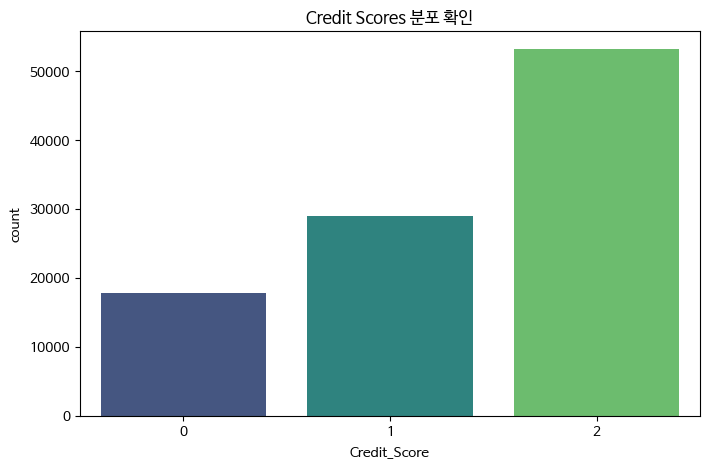

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
from sklearn.metrics import accuracy_score, classification_report

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 타겟 변수 분포 확인 (Credit Score)
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Credit_Score', palette='viridis')
plt.title('Credit Scores 분포 확인')
plt.show()
# 0: Good, 1: Poor, 2: Standard
# Standard 등급이 53174로 가장 높은 수치를 보이고, Poor 등급이 28998, Good 등급이 17828로 가장 낮은 수치를 기록했다.
# 고등급 고객이 적은 수치를 보이는 것은 자연스러운 현상으로 데이터 불균형이 보이고 있다.
# 이를 해결하기 위해 모델링 과정에서 불균형 해결 기법을 고려해봐야 할 것 같다.


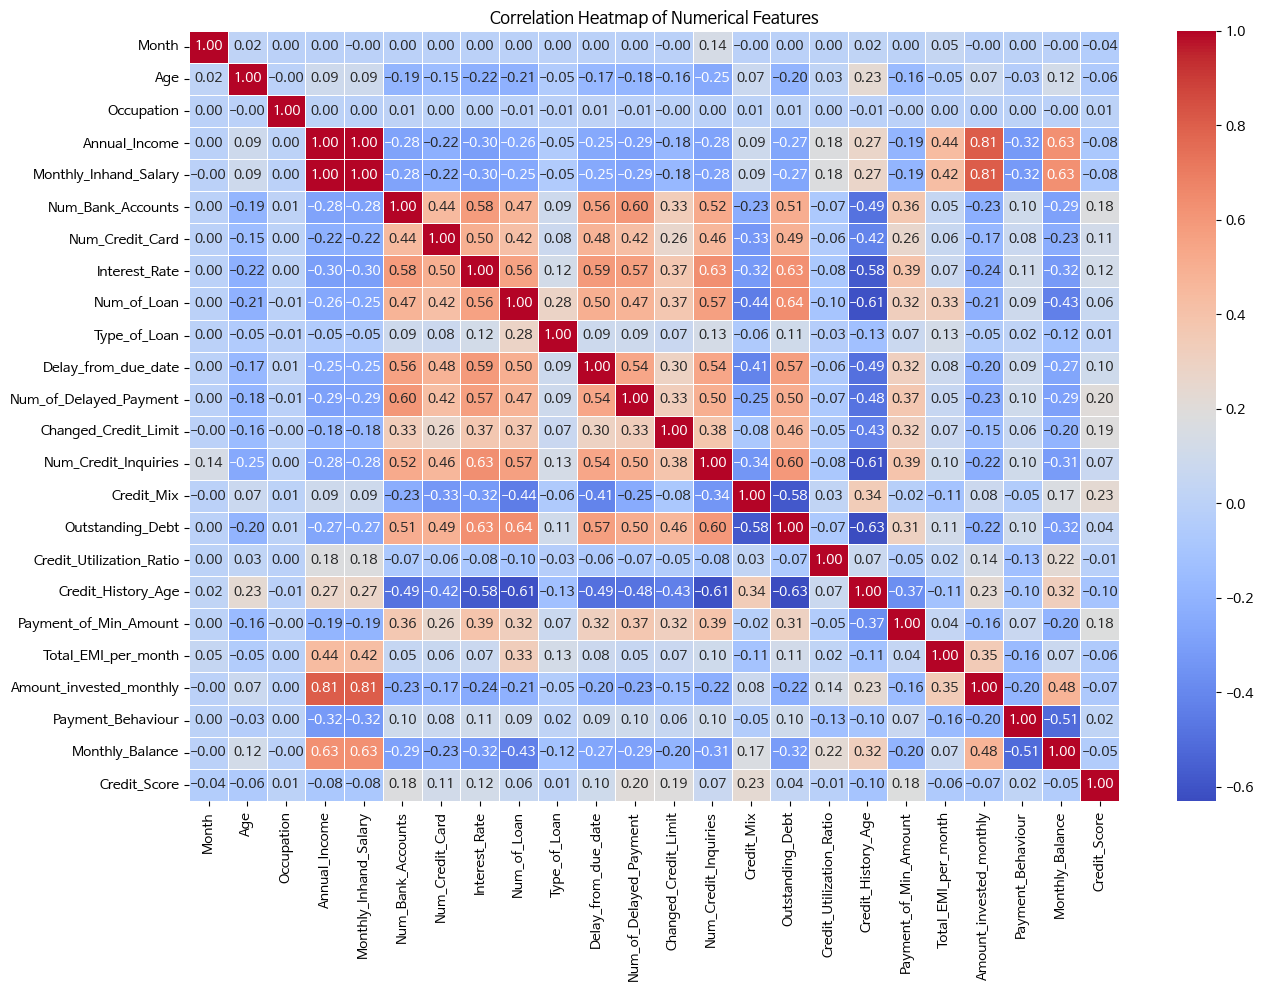

In [ ]:
# 수치형 변수 간 상관관계 히트맵
plt.figure(figsize=(15, 10))
numeric_df = data.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()
# 수치형 변수 간의 히트맵 확인 결과, 높은 상관관계를 띄는 변수들이 존재했다.
# Annual_Income, Monthly_Inhand_Salary와 Amount_invested_monthly사이 상관계수가 둘다 0.81이다.
# -> 개인의 연간 소득 및 월별 기본급여가 높을 수록 월별 투자금액이 같이 상승한다.

# Outstanding_Debt와 Credit_History_Age의 상관계수가 -0.63으로 가장 작은 음의 상관계수를 보이고 있다.
# -> 신용 거래 기간이 늘면 미지급 잔액이 주는 경우 많은 것으로 보인다.

/tmp/ipykernel_4673/3414620584.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Credit_Score', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_4673/3414620584.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Credit_Score', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_4673/3414620584.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Credit_Score', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_4673/3414620584.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

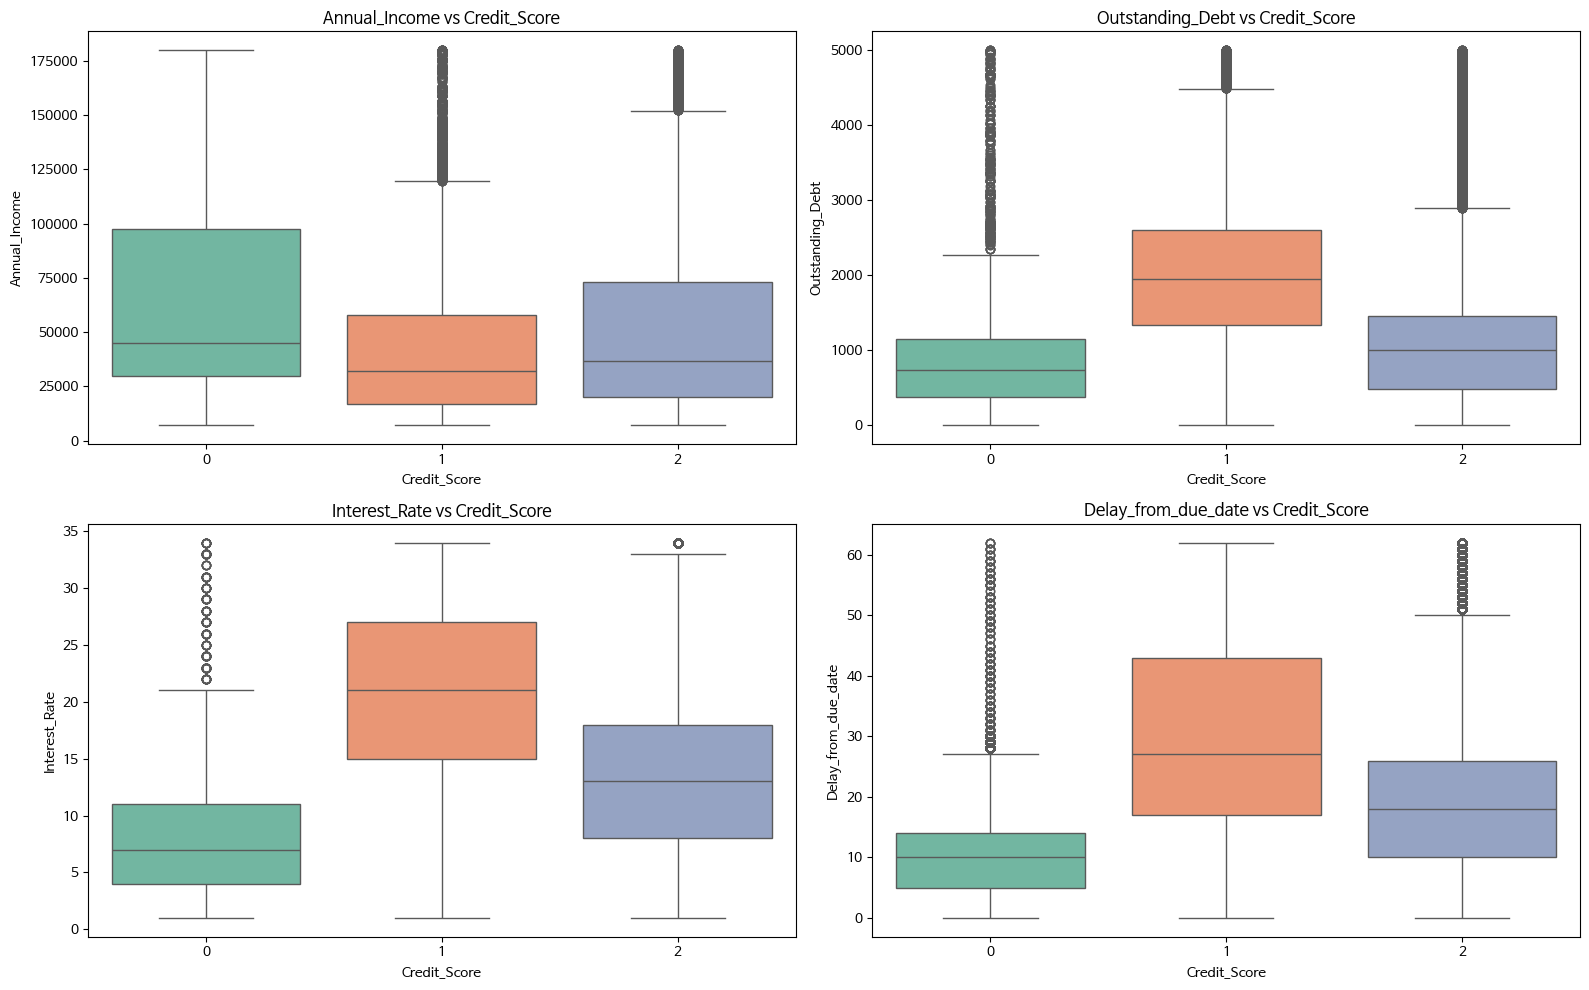

In [ ]:
# 주요 수치형 변수 등급별 분포 확인
key_features = ['Annual_Income', 'Outstanding_Debt', 'Interest_Rate', 'Delay_from_due_date']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(data=data, x='Credit_Score', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Credit_Score')

plt.tight_layout()
plt.show()

# 숫자 0(Good 등급)의 경우, 연봉이 가장 높고, 빚, 연체 일수 매우 낮다. 우량 고객이다.
# 숫자 1(Poor 등급)의 경우, 연봉이 가장 낮은 편이고, 빚, 이자율, 연체 일수가 높다. 위험 고객이다.
# 숫자 2(Standard 등급)의 경우, 모든 지표가 0~1사이에 위치해있다.

/tmp/ipykernel_3905/1727486292.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x='Credit_Score', y=col, ax=axes[i], palette='pastel')
/tmp/ipykernel_3905/1727486292.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x='Credit_Score', y=col, ax=axes[i], palette='pastel')
/tmp/ipykernel_3905/1727486292.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x='Credit_Score', y=col, ax=axes[i], palette='pastel')
/tmp/ipykernel_3905/1727486292.py:21: FutureWarning: 

Passing `palette` without assigni

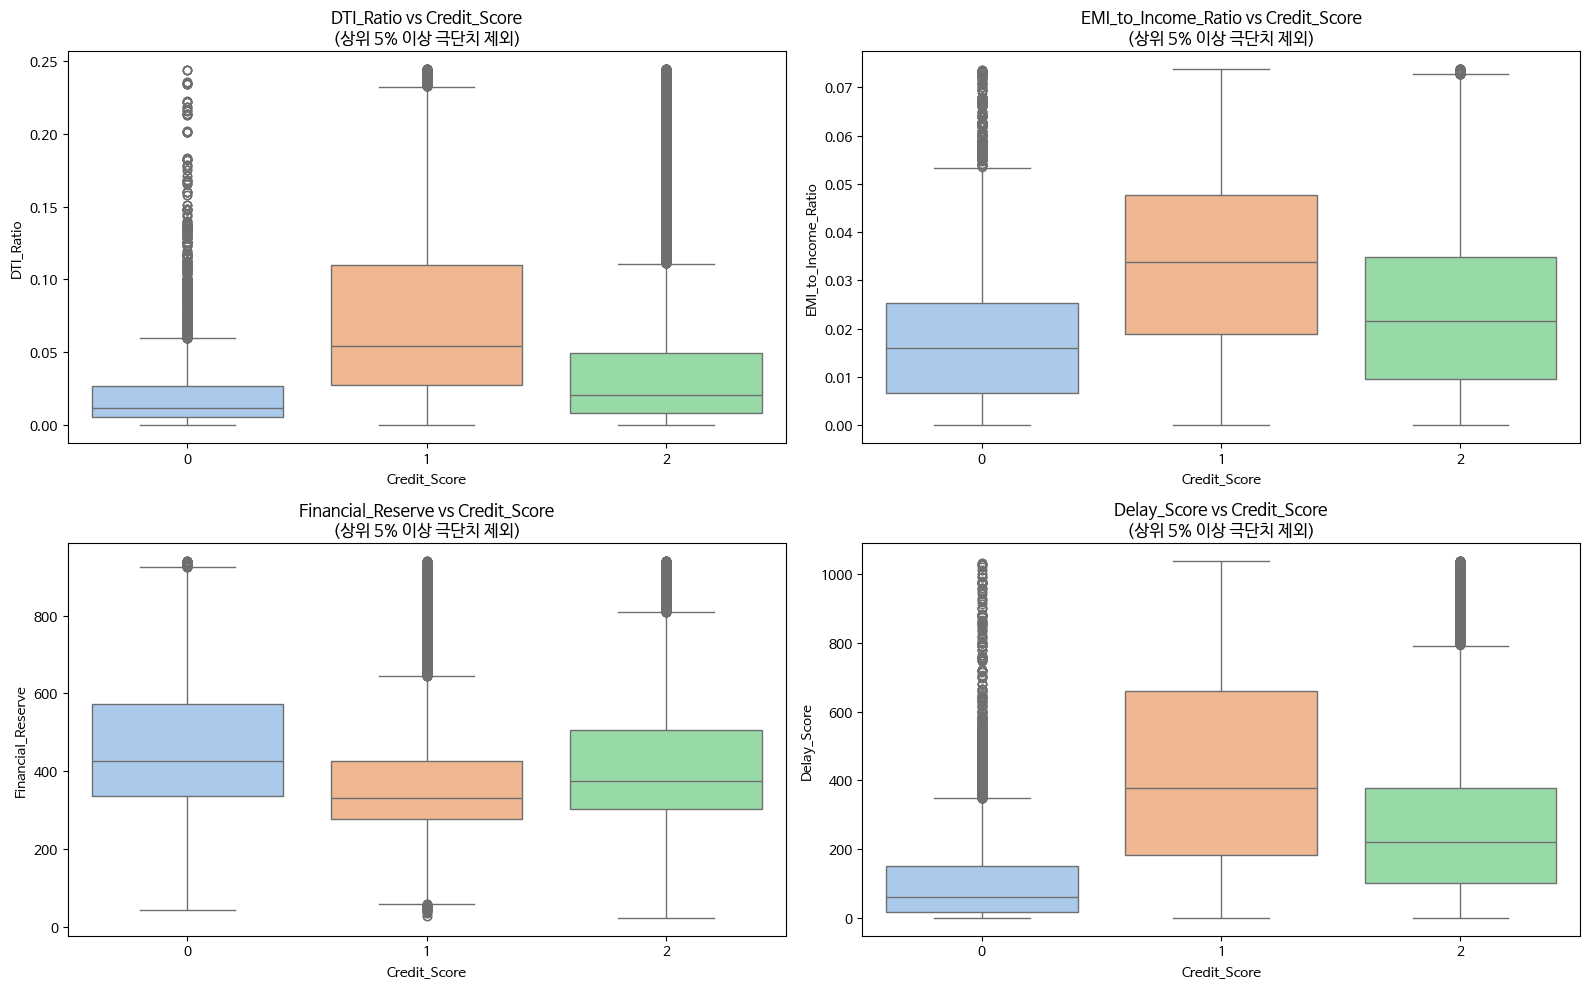

In [3]:
# 파생 변수 생성

# 소득 대비 부채 비율
data['DTI_Ratio'] = data['Outstanding_Debt'] / (data['Annual_Income'] + 1e-6)
# 월 소득 대비 고정 지출 비율
data['EMI_to_Income_Ratio'] = data['Total_EMI_per_month'] / (data['Monthly_Inhand_Salary'] + 1e-6)
# 잉여 금융 자산
data['Financial_Reserve'] = data['Monthly_Balance'] + data['Amount_invested_monthly']
# 연체 위험 지수
data['Delay_Score'] = data['Num_of_Delayed_Payment'] * data['Delay_from_due_date']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

derived_features = ['DTI_Ratio', 'EMI_to_Income_Ratio', 'Financial_Reserve', 'Delay_Score']

for i, col in enumerate(derived_features):
    q_high = data[col].quantile(0.95)
    temp_df = data[data[col] < q_high]

    sns.boxplot(data=temp_df, x='Credit_Score', y=col, ax=axes[i], palette='pastel')
    axes[i].set_title(f'{col} vs Credit_Score\n(상위 5% 이상 극단치 제외)')

plt.tight_layout()
plt.show()

In [ ]:
# 1. DTI_Ratio (소득 대비 부채 비율)
# 0(Good)등급은 바닥에 붙어있고, 1(Poor)등급은 박스가 가장 위에 있다.

# 2. EMI_to_Income_Ratio (월 소득 대비 고정지출 비중)
# 1(Poor)등급의 고객들은 나머지 두 고객들에 비해 월급 대비 고정지출이 높다. -> 당장 사용할 현금이 부족하다.

# 3. Financial_Reserve (잉여 금융 자산)
# 0(Good)등급의 고객들이 통잔 잔고, 투자금을 합친 '여윳돈'이 높다. 하지만 2(Standard)등급의 고객들과 큰 차이는 없어보인다.

# 4. Delay_Score (종합 연체 위험 지수)
# 0(Good)등급의 고객들은 바닥에 붙어있는 반면, 1(Poor)등급의 고객의 경우 박스 자체가 매우 넓고 높게 분포되어 있다.
# 위험 및 불량 고객을 솎아내는데 중요한 역할을 할 것임을 보여준다.

# TabNet

In [ ]:
# 데이터 분리
X = data.drop(columns=['Credit_Score'])
y = data['Credit_Score'].values

# X 데이터의 전체 컬럼 중 범주형 변수가 몇 번째(index)에 위치하는지 리스트로 추출
cat_idxs = [i for i, col in enumerate(X.columns) if col in categorical_columns]
# 해당 범주형 변수 안에 각각 클래스 종류 추출
cat_dims = [X[col].nunique() for col in X.columns if col in categorical_columns]

# 스케일링은 연속형(숫자) 변수에만 적용
num_cols = [col for col in X.columns if col not in categorical_columns]
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# 최종 분할
X_values = X.values
X_train, X_test, y_train, y_test = train_test_split(X_values, y, test_size=0.2, random_state=42)

# 3. TabNet 모델 학습 및 평가
clf = TabNetClassifier(
    cat_idxs=cat_idxs,          # 범주형 컬럼 위치(데이터 서열, 크기 비교X)
    cat_dims=cat_dims,          # 범주형 컬럼의 종류 수
    cat_emb_dim=5,              # 0, 1, 2를 5차원 벡터로 변환(임베딩)
    # 모델 복잡도
    n_d=16, n_a=16,
    n_steps=4,
    # 과적합 방지
    gamma=1.5,
    lambda_sparse=1e-3,
    # 최적화
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2, weight_decay=1e-5),
    scheduler_params={"step_size":50, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax'
)

clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_name=['train', 'valid'],
    eval_metric=['accuracy'],
    max_epochs=200,            # 최대 200번 반복
    patience=30,               # 30번 반복 동안 성능 향성 없으면 조기 종료
    batch_size=1024,
    virtual_batch_size=128,
    weights=1                   # 클래스 불균형 자동 조정
)

# 예측 및 성능 평가
train_preds = clf.predict(X_train)
train_acc = accuracy_score(y_train, train_preds)

test_preds = clf.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)

# 최종 성능 출력
print(f"\n최종 Train Accuracy: {train_acc:.4f}")
print(f"최종 Test Accuracy:  {test_acc:.4f}")
print("\nClassification Report (Test 데이터 기준):")

print(classification_report(y_test, test_preds, target_names=target_encoder.classes_))

--- TabNet 모델 학습 시작 ---


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.85712 | train_accuracy: 0.66632 | valid_accuracy: 0.66535 |  0:00:06s
epoch 1  | loss: 0.69673 | train_accuracy: 0.67168 | valid_accuracy: 0.66955 |  0:00:13s
epoch 2  | loss: 0.67479 | train_accuracy: 0.67538 | valid_accuracy: 0.6722  |  0:00:19s
epoch 3  | loss: 0.62872 | train_accuracy: 0.73155 | valid_accuracy: 0.72245 |  0:00:26s
epoch 4  | loss: 0.56016 | train_accuracy: 0.75164 | valid_accuracy: 0.7379  |  0:00:32s
epoch 5  | loss: 0.52209 | train_accuracy: 0.76196 | valid_accuracy: 0.7441  |  0:00:39s
epoch 6  | loss: 0.49579 | train_accuracy: 0.77579 | valid_accuracy: 0.75675 |  0:00:45s
epoch 7  | loss: 0.47327 | train_accuracy: 0.77145 | valid_accuracy: 0.7563  |  0:00:52s
epoch 8  | loss: 0.46184 | train_accuracy: 0.78008 | valid_accuracy: 0.76    |  0:00:58s
epoch 9  | loss: 0.44752 | train_accuracy: 0.79074 | valid_accuracy: 0.76705 |  0:01:05s
epoch 10 | loss: 0.44424 | train_accuracy: 0.78409 | valid_accuracy: 0.76365 |  0:01:12s
epoch 11 | loss: 0.43

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



최종 Train Accuracy: 0.8907
최종 Test Accuracy:  0.8135

Classification Report (Test 데이터 기준):
              precision    recall  f1-score   support

        Good       0.71      0.90      0.80      3527
        Poor       0.78      0.87      0.82      5874
    Standard       0.89      0.76      0.82     10599

    accuracy                           0.81     20000
   macro avg       0.79      0.84      0.81     20000
weighted avg       0.82      0.81      0.81     20000



# TabTransformer

In [ ]:
!pip install tab-transformer-pytorch

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


from tab_transformer_pytorch import TabTransformer

X = data.drop(columns=['Credit_Score'])
y = data['Credit_Score'].values

# TabTransformer는 범주형(cat) 데이터와 연속형(cont) 데이터를 분리해서 입력
X_cat = X[categorical_columns].values
num_cols = [col for col in X.columns if col not in categorical_columns]
X_cont = X[num_cols].values

# 범주형 변수의 클래스 개수(튜플 형태) 추출
cat_dims = tuple([X[col].nunique() for col in categorical_columns])

# 스케일링
scaler = RobustScaler()
X_cont = scaler.fit_transform(X_cont)

# Train / Test 분할
X_cat_train, X_cat_test, X_cont_train, X_cont_test, y_train, y_test = train_test_split(
    X_cat, X_cont, y, test_size=0.2, random_state=42
)

# 클래스 불균형 해결을 위한 가중치 계산
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Numpy 배열을 PyTorch Tensor로 변환
train_dataset = TensorDataset(
    torch.tensor(X_cat_train, dtype=torch.long),
    torch.tensor(X_cont_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_cat_test, dtype=torch.long),
    torch.tensor(X_cont_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

# 데이터 세트화
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)


# TabTransformer 모델 정의 (과적합 방지 설계)
model = TabTransformer(
    categories=cat_dims,        # 각 범주형 변수의 종류 개수
    num_continuous=len(num_cols),# 연속형 변수의 개수
    dim=32,                     # 임베딩 및 어텐션 차원 (기본 32)
    dim_out=len(classes),       # 최종 출력 클래스 개수 (3개)
    depth=6,                    # 트랜스포머 레이어 깊이
    heads=8,                    # 어텐션 헤드 개수
    attn_dropout=0.2,           # [과적합 방지] 어텐션 드롭아웃
    ff_dropout=0.2,             # [과적합 방지] 피드포워드 드롭아웃
    mlp_hidden_mults=(4, 2),    # 마지막 MLP 레이어의 차원 비율
    mlp_act=nn.ReLU(),
).to(device)

# 손실 함수에 클래스 가중치(weights) 적용하여 불균형 완화
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))

# [과적합 방지] AdamW 사용 및 weight_decay 적용
optimizer = optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-3)

# 학습률 스케줄러: 성능 향상이 멈추면 학습률을 줄임
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)


# 모델링
epochs = 200
patience_limit = 15 # 조기 종료기준
best_val_acc = 0
patience_counter = 0

for epoch in range(epochs):
  # 훈련 모드
    model.train()
    train_correct = 0
    train_total = 0

# 1024개씩 묶어주는 데이터를 꺼내서 학습
    for cat_batch, cont_batch, y_batch in train_loader:
      # 데이터 묶음을 gpu에 올림
        cat_batch, cont_batch, y_batch = cat_batch.to(device), cont_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()                       # 기울기(오차기록)초기화
        outputs = model(cat_batch, cont_batch)      # 예측값 뽑기
        loss = criterion(outputs, y_batch)          # loss 계산
        loss.backward()                             # 오차 역전파
        optimizer.step()                            # 가중치 업데이트

        _, predicted = torch.max(outputs, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()

    train_acc = train_correct / train_total

    # 평가 모드
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for cat_batch, cont_batch, y_batch in test_loader:
            cat_batch, cont_batch, y_batch = cat_batch.to(device), cont_batch.to(device), y_batch.to(device)
            outputs = model(cat_batch, cont_batch)
            _, predicted = torch.max(outputs, 1)
            val_total += y_batch.size(0)
            val_correct += (predicted == y_batch).sum().item()

    val_acc = val_correct / val_total

    # 스케줄러 업데이트 (검증 정확도 기준)
    scheduler.step(val_acc)

    # 출력 간소화: 10 에포크마다 또는 성능 갱신 시 출력
    if (epoch + 1) % 10 == 0 or val_acc > best_val_acc:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # 조기 종료(Early Stopping) 로직
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # 가장 성능이 좋은 모델의 상태를 저장
        torch.save(model.state_dict(), 'best_tabtransformer.pth')
    else:
        patience_counter += 1

    if patience_counter >= patience_limit:
        print(f"\n[Early Stopping] {epoch+1} 에포크에서 조기 종료되었습니다. (Patience: {patience_limit} 초과)")
        break


# 최종 예측 및 평가
model.load_state_dict(torch.load('best_tabtransformer.pth', weights_only=True))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for cat_batch, cont_batch, y_batch in test_loader:
        cat_batch, cont_batch = cat_batch.to(device), cont_batch.to(device)
        outputs = model(cat_batch, cont_batch)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

final_test_acc = accuracy_score(all_targets, all_preds)


print(f"최고 Validation (Test) Accuracy: {final_test_acc:.4f}")
print("\nClassification Report (Test 데이터 기준):")
print(classification_report(all_targets, all_preds, target_names=target_encoder.classes_))

Epoch [1/200] | Train Acc: 0.6074 | Val Acc: 0.7177
Epoch [2/200] | Train Acc: 0.7303 | Val Acc: 0.7310
Epoch [3/200] | Train Acc: 0.7458 | Val Acc: 0.7498
Epoch [4/200] | Train Acc: 0.7551 | Val Acc: 0.7562
Epoch [6/200] | Train Acc: 0.7693 | Val Acc: 0.7627
Epoch [9/200] | Train Acc: 0.7871 | Val Acc: 0.7663
Epoch [10/200] | Train Acc: 0.7939 | Val Acc: 0.7710
Epoch [11/200] | Train Acc: 0.7980 | Val Acc: 0.7766
Epoch [14/200] | Train Acc: 0.8139 | Val Acc: 0.7825
Epoch [16/200] | Train Acc: 0.8250 | Val Acc: 0.7857
Epoch [17/200] | Train Acc: 0.8264 | Val Acc: 0.7861
Epoch [20/200] | Train Acc: 0.8436 | Val Acc: 0.7907
Epoch [23/200] | Train Acc: 0.8554 | Val Acc: 0.7929
Epoch [25/200] | Train Acc: 0.8655 | Val Acc: 0.7950
Epoch [26/200] | Train Acc: 0.8680 | Val Acc: 0.7956
Epoch [27/200] | Train Acc: 0.8729 | Val Acc: 0.8010
Epoch [28/200] | Train Acc: 0.8759 | Val Acc: 0.8030
Epoch [30/200] | Train Acc: 0.8868 | Val Acc: 0.8006
Epoch [31/200] | Train Acc: 0.8907 | Val Acc: 0.8041

개선사항
- 연속형 변수만 따로 부분 스케일링
- 임베딩 도입
- 클래스 불균형 해결 - compute_class_weight, weight_decay, criterion weight -> recall 상승
- 조기종료 - patience 설정으로 과적합 방지
